# Chapter 10 — Neural learning about edges and corners: intro to convolutional neural networks

> *Grokking Deep Learning* — Andrew W. Trask

Chapter ini membahas ide utama **Convolutional Neural Networks (CNN)** melalui konsep yang sangat penting: **reusing weights**. Fokusnya bukan sekadar “menggeser kernel”, tetapi memahami mengapa satu set weights yang sama dapat digunakan untuk mendeteksi pola di banyak lokasi gambar.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita diharapkan dapat:

1. Menjelaskan hubungan **overfitting**, jumlah parameter, dan *weight-to-data ratio*.
2. Memahami prinsip **reusing weights in multiple places**.
3. Menjelaskan fungsi **convolutional kernel** sebagai *mini linear layer*.
4. Memahami bagaimana kernel berpindah dari satu posisi ke posisi lain pada gambar.
5. Menjelaskan mengapa beberapa kernel menghasilkan beberapa *prediction matrices*.
6. Memahami ide **max pooling** yang dibahas pada chapter.
7. Menghubungkan implementasi convolution dengan operasi NumPy.
8. Membaca output training/testing dari implementasi CNN pada chapter.

## Chapter Roadmap

**Reusing weights → Convolutional layer → Kernel scanning → Multiple kernels → Pooling → NumPy implementation → Training result**

Chapter ini masih menggunakan MNIST sebagai contoh, tetapi sudut pandangnya bergeser dari jaringan fully connected pada Chapter 9 menuju struktur yang memanfaatkan lokasi spasial gambar.

## Reusing Weights in Multiple Places

Buku menekankan aturan sederhana:

> Jika sebuah neural network perlu mendeteksi **feature yang sama di banyak tempat**, gunakan **weights yang sama**.

Masalah yang ingin dikurangi adalah **overfitting**. Jika setiap lokasi gambar memiliki weights yang berbeda, model harus belajar secara terpisah bagaimana mendeteksi pola yang sama pada setiap lokasi. Hal tersebut meningkatkan jumlah parameter dan dapat memperburuk *weight-to-data ratio*.

Dengan **structure**, weights sengaja digunakan kembali pada banyak posisi. Dengan begitu, satu set weights memperoleh lebih banyak kesempatan untuk belajar pola yang sama.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Perbandingan konseptual jumlah parameter.
# Angka di sini hanya ilustrasi untuk menjelaskan ide,
# bukan angka eksperimen dari buku.
dense_parameters = 28 * 28 * 100
kernel_parameters = 3 * 3 * 16

print("Dense layer parameters:", dense_parameters)
print("16 kernels of size 3x3:", kernel_parameters)

Dense layer parameters: 78400
16 kernels of size 3x3: 144


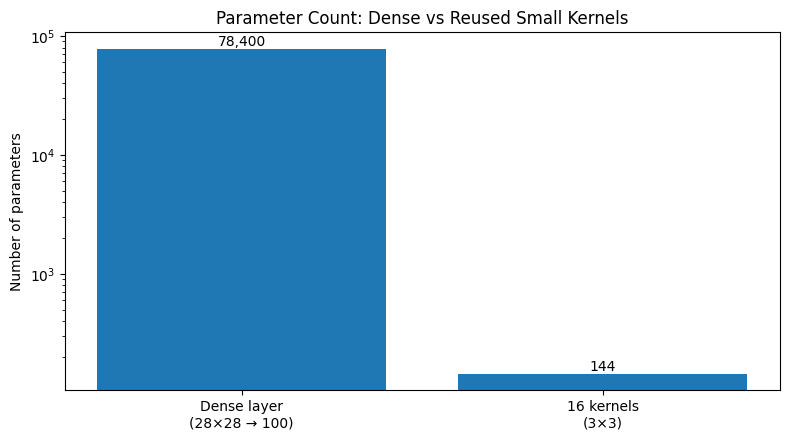

In [2]:
labels = ["Dense layer\n(28×28 → 100)", "16 kernels\n(3×3)"]
values = [dense_parameters, kernel_parameters]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(labels, values)
plt.ylabel("Number of parameters")
plt.title("Parameter Count: Dense vs Reused Small Kernels")
plt.yscale("log")
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:,}",
             ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Interpretasi

Grafik ini **bersifat ilustratif**, bukan hasil eksperimen dari buku. Tujuannya memperjelas gagasan Chapter 10: sebuah convolutional layer menggunakan kernel kecil yang sama berulang kali, sehingga jumlah parameter yang harus disimpan jauh lebih kecil daripada membuat koneksi dense yang terpisah untuk seluruh lokasi.

Buku menyebut bahwa pengurangan parameter melalui *structure* dapat membuat model lebih robust terhadap overfitting sekaligus tetap ekspresif.

## The Convolutional Layer

Buku menggambarkan convolutional layer sebagai kumpulan **mini linear layers** yang digunakan kembali pada setiap posisi.

Satu **convolutional kernel** dapat dipandang sebagai *baby linear layer* dengan sedikit input dan satu output. Contoh yang ditampilkan buku adalah kernel berukuran **3 × 3**.

Prosesnya:

1. Kernel berada pada satu posisi gambar.
2. Kernel menghasilkan satu prediction.
3. Kernel bergeser satu pixel.
4. Prediction dilakukan lagi.
5. Proses berlanjut sampai seluruh posisi yang memungkinkan diproses.

Jika input berukuran **8 × 8** dan kernel berukuran **3 × 3**, maka tanpa padding output spasialnya menjadi **6 × 6**.

In [3]:
# Contoh ukuran output convolution tanpa padding.
input_rows, input_cols = 8, 8
kernel_rows, kernel_cols = 3, 3

output_rows = input_rows - kernel_rows + 1
output_cols = input_cols - kernel_cols + 1

print(f"Input : {input_rows}×{input_cols}")
print(f"Kernel: {kernel_rows}×{kernel_cols}")
print(f"Output: {output_rows}×{output_cols}")

Input : 8×8
Kernel: 3×3
Output: 6×6


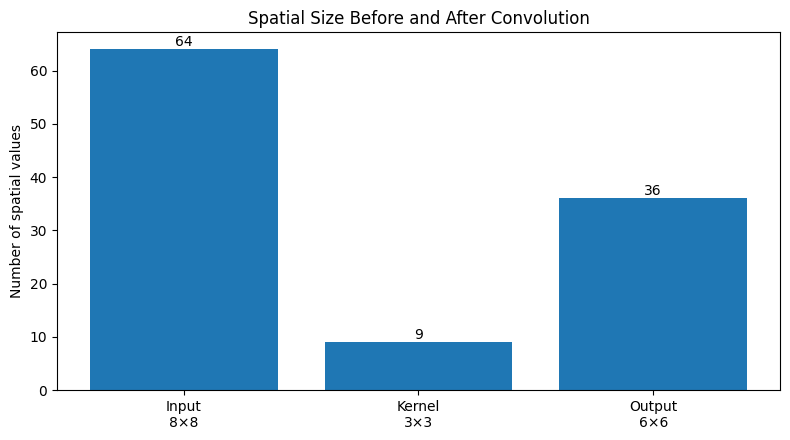

In [4]:
sizes = [input_rows * input_cols, kernel_rows * kernel_cols, output_rows * output_cols]
names = ["Input\n8×8", "Kernel\n3×3", "Output\n6×6"]

plt.figure(figsize=(8, 4.5))
plt.bar(names, sizes)
plt.ylabel("Number of spatial values")
plt.title("Spatial Size Before and After Convolution")
for i, v in enumerate(sizes):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Kernel Scanning: Satu Weights, Banyak Posisi

Visual yang paling tepat untuk konsep ini bukan sekadar grafik, tetapi **simulasi sliding window**.

Kernel yang sama ditempatkan pada posisi berbeda pada input. Walaupun lokasi berubah, **nilai weights kernel tidak berubah**. Yang berubah hanyalah bagian gambar yang sedang dibaca.

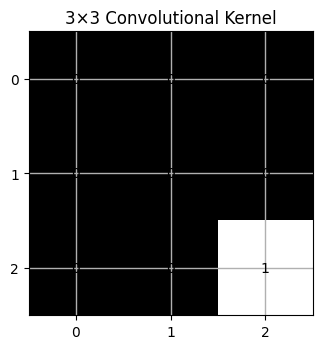

In [5]:
# Kernel 3×3 yang ditampilkan dalam buku.
kernel = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 1]
])

plt.figure(figsize=(3.6, 3.6))
plt.imshow(kernel, cmap="gray", vmin=0, vmax=1)
plt.xticks(range(3)); plt.yticks(range(3))
plt.grid(True, linewidth=1)
plt.title("3×3 Convolutional Kernel")
for r in range(3):
    for c in range(3):
        plt.text(c, r, str(kernel[r, c]), ha="center", va="center")
plt.tight_layout()
plt.show()

Kernel di atas mengikuti contoh 3 × 3 yang ditampilkan pada Chapter 10. Kernel tersebut merupakan contoh bagaimana sekumpulan weights kecil dapat dipakai berulang kali untuk mencari pola lokal.

**Catatan:** nilai kernel yang ditampilkan di sini adalah contoh dari sumber. Dalam training nyata, weights kernel akan dipelajari melalui proses learning.

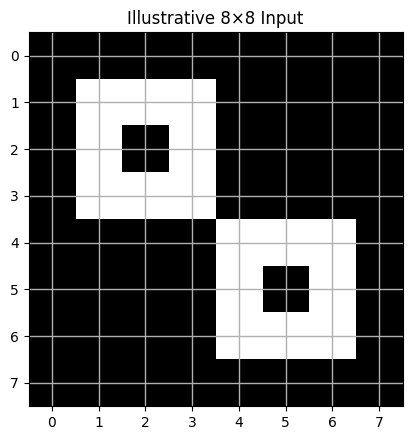

In [6]:
# Input ilustratif 8×8 untuk memperlihatkan proses sliding window.
# Ini bukan gambar MNIST/output eksperimen buku.
image_demo = np.array([
    [0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,0],
    [0,1,0,1,0,0,0,0],
    [0,1,1,1,0,0,0,0],
    [0,0,0,0,1,1,1,0],
    [0,0,0,0,1,0,1,0],
    [0,0,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0]
], dtype=float)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(image_demo, cmap="gray")
plt.xticks(range(8)); plt.yticks(range(8))
plt.grid(True, linewidth=1)
plt.title("Illustrative 8×8 Input")
plt.tight_layout()
plt.show()

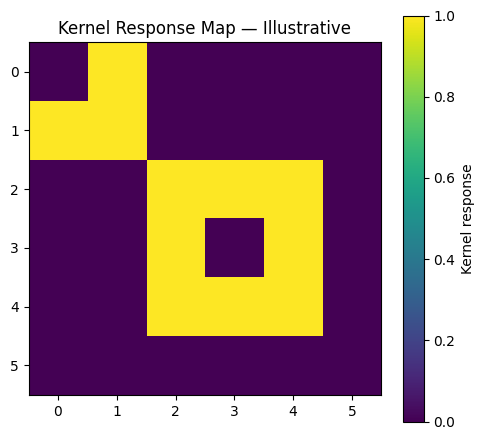

Output shape: (6, 6)


In [7]:
def simple_convolution(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    out = np.zeros((h-kh+1, w-kw+1))
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            patch = image[r:r+kh, c:c+kw]
            out[r, c] = np.sum(patch * kernel)
    return out

conv_demo = simple_convolution(image_demo, kernel)

plt.figure(figsize=(5, 4.5))
plt.imshow(conv_demo, cmap="viridis")
plt.colorbar(label="Kernel response")
plt.xticks(range(conv_demo.shape[1]))
plt.yticks(range(conv_demo.shape[0]))
plt.title("Kernel Response Map — Illustrative")
plt.tight_layout()
plt.show()

print("Output shape:", conv_demo.shape)

### Apa yang terlihat?

Output menjadi **6 × 6**, karena kernel 3 × 3 dapat ditempatkan pada 36 posisi berbeda di dalam input 8 × 8.

Setiap posisi menghasilkan satu angka. Angka tersebut menunjukkan seberapa kuat bagian gambar lokal tersebut menghasilkan respons terhadap weights kernel.

Jadi, convolution bukan “satu prediksi untuk satu gambar”, melainkan **banyak prediksi lokal menggunakan weights yang sama**.

## Multiple Kernels

Buku menjelaskan bahwa convolutional layer biasanya memiliki **banyak kernels**.

Untuk input 8 × 8 dengan empat kernel 3 × 3:

- setiap kernel menghasilkan satu matriks **6 × 6**;
- terdapat empat prediction matrices;
- setiap kernel dapat belajar mendeteksi pola yang berbeda.

Contoh yang dijelaskan buku mencakup kernel yang merespons segmen garis horizontal dan garis diagonal.

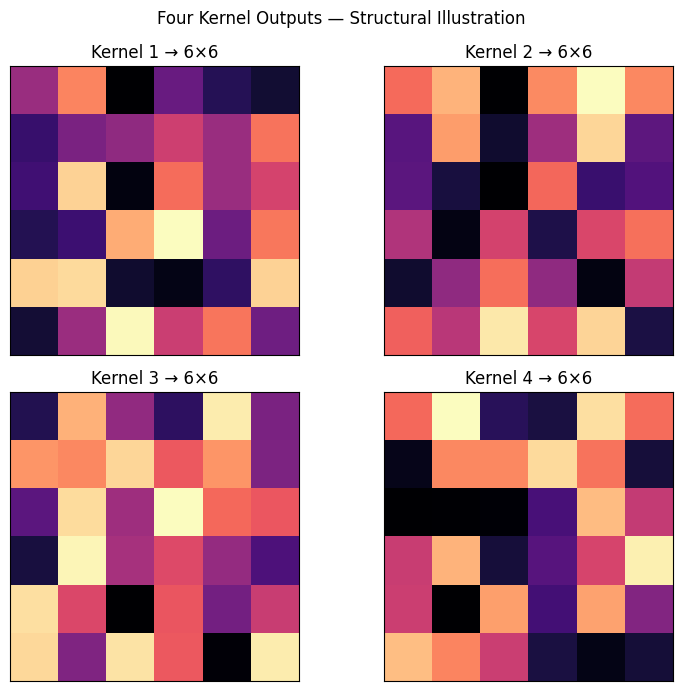

In [8]:
# Ilustrasi struktur output dari 4 kernels.
# Ukuran mengikuti contoh buku: 4 × (6×6).
np.random.seed(1)
four_kernel_outputs = np.random.rand(4, 6, 6)

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(four_kernel_outputs[i], cmap="magma")
    ax.set_title(f"Kernel {i+1} → 6×6")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Four Kernel Outputs — Structural Illustration", y=0.98)
plt.tight_layout()
plt.show()

**Catatan akurasi:** nilai pada empat matriks di atas dibuat secara acak hanya untuk memvisualisasikan bentuk output. Yang berasal dari sumber adalah **struktur**: empat kernel 3 × 3 pada input 8 × 8 menghasilkan empat matriks 6 × 6. Buku tidak memberikan seluruh angka matriks tersebut sebagai data numerik untuk direproduksi.

## Pooling: Menggabungkan Respons dari Beberapa Kernels

Chapter 10 menjelaskan tiga cara untuk menggabungkan empat prediction matrices secara elementwise:

- **sum pooling** → menjumlahkan nilai pada posisi yang sama;
- **mean pooling** → mengambil rata-rata;
- **max pooling** → mengambil nilai terbesar.

Buku menyatakan bahwa **max pooling** merupakan versi yang paling populer dalam pembahasan tersebut. Untuk setiap posisi, kita melihat output dari seluruh kernel dan mengambil nilai maksimum.

In [9]:
# Contoh pooling pada satu posisi.
kernel_responses = np.array([0.10, 0.35, 0.90, 0.20])

pool_values = {
    "Sum": kernel_responses.sum(),
    "Mean": kernel_responses.mean(),
    "Max": kernel_responses.max()
}

print("Kernel responses:", kernel_responses)
print(pool_values)

Kernel responses: [0.1  0.35 0.9  0.2 ]
{'Sum': np.float64(1.55), 'Mean': np.float64(0.3875), 'Max': np.float64(0.9)}


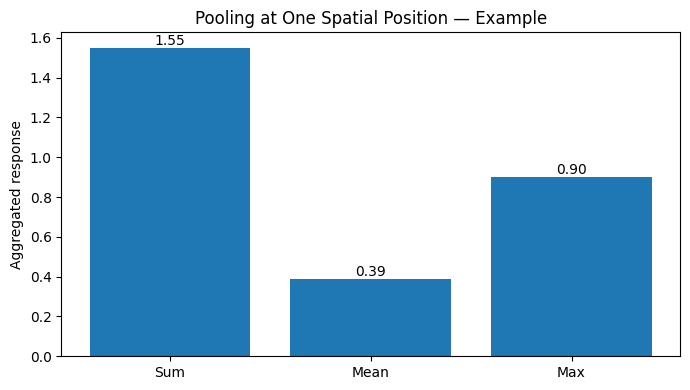

In [10]:
names = list(pool_values.keys())
values = list(pool_values.values())

plt.figure(figsize=(7, 4))
bars = plt.bar(names, values)
plt.ylabel("Aggregated response")
plt.title("Pooling at One Spatial Position — Example")
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Contoh ini hanya menunjukkan mekanisme pooling dengan empat angka ilustratif. Inti konsep dari sumber adalah bahwa **max pooling mempertahankan respons terkuat pada setiap posisi** sehingga representasi yang diteruskan ke layer berikutnya tetap membawa sinyal pola yang paling kuat.

## A Simple Implementation in NumPy

Implementasi buku menggunakan pendekatan yang menarik: setiap subregion gambar diperlakukan seperti sebuah input kecil.

Untuk input MNIST berukuran **28 × 28** dan kernel **3 × 3**:

- setiap kernel membaca subregion 3 × 3;
- subregion tersebut dikumpulkan dari berbagai posisi;
- seluruh subregion kemudian dirapikan menjadi bentuk yang dapat diproses dengan operasi dot product;
- `flattened_input.dot(kernels)` menghasilkan output untuk banyak kernel sekaligus.

Buku menekankan bahwa pendekatan ini membuat implementasi lebih sederhana dan lebih cepat karena banyak prediksi dapat dihitung sebagai satu operasi matrix multiplication.

In [11]:
# Inti mekanisme pemilihan subregion seperti pada source.
def get_image_section(layer, row_from, row_to, col_from, col_to):
    subsection = layer[:, row_from:row_to, col_from:col_to]
    return subsection.reshape(
        -1, 1, row_to-row_from, col_to-col_from
    )

# Demo batch kecil agar struktur mudah diperiksa.
demo_batch = np.arange(2*5*5).reshape(2,5,5)

section = get_image_section(demo_batch, 1, 4, 1, 4)

print("Original batch shape :", demo_batch.shape)
print("Selected section shape:", section.shape)

Original batch shape : (2, 5, 5)
Selected section shape: (2, 1, 3, 3)


In [12]:
# Demonstrasi dot product untuk beberapa kernel.
kernel_rows, kernel_cols, num_kernels = 3, 3, 4

flattened_demo = section.reshape(section.shape[0], -1)
demo_kernels = np.random.random((kernel_rows*kernel_cols, num_kernels))

# Ambil satu contoh input agar dimensi dot product jelas.
one_section = section[0].reshape(1, -1)
kernel_output_demo = one_section.dot(demo_kernels)

print("Flattened section:", one_section.shape)
print("Kernels           :", demo_kernels.shape)
print("Kernel output     :", kernel_output_demo.shape)

Flattened section: (1, 9)
Kernels           : (9, 4)
Kernel output     : (1, 4)


### Hubungan Dimensi

Pada implementasi chapter:

- `kernel_rows × kernel_cols = 3 × 3` → **9 input** untuk satu kernel.
- `num_kernels = 16` → terdapat **16 kernel**.
- sehingga matriks `kernels` memiliki bentuk **(9, 16)**.

Ini adalah cara lain untuk melihat convolutional layer sebagai operasi linear yang dilakukan berulang pada banyak subregion.

In [13]:
# Konfigurasi utama dari source Chapter 10.
alpha, iterations = 2, 300
pixels_per_image, num_labels = 784, 10
batch_size = 128
input_rows, input_cols = 28, 28
kernel_rows, kernel_cols = 3, 3
num_kernels = 16

hidden_size = ((input_rows - kernel_rows) *
               (input_cols - kernel_cols)) * num_kernels

kernels_shape = (kernel_rows * kernel_cols, num_kernels)
weights_1_2_shape = (hidden_size, num_labels)

print("kernels shape     :", kernels_shape)
print("hidden_size       :", hidden_size)
print("weights_1_2 shape :", weights_1_2_shape)

kernels shape     : (9, 16)
hidden_size       : 10000
weights_1_2 shape : (10000, 10)


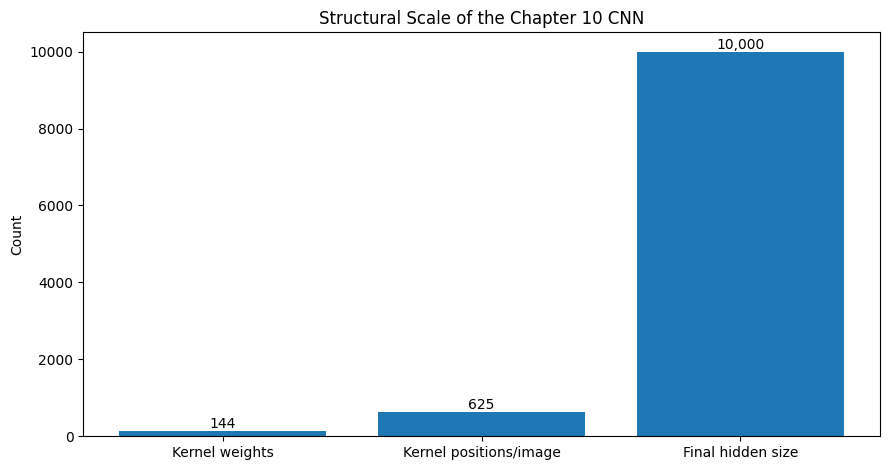

In [14]:
config_labels = [
    "Kernel weights",
    "Kernel positions/image",
    "Final hidden size"
]
config_values = [
    kernel_rows * kernel_cols * num_kernels,
    (input_rows-kernel_rows) * (input_cols-kernel_cols),
    hidden_size
]

plt.figure(figsize=(9, 4.8))
bars = plt.bar(config_labels, config_values)
plt.ylabel("Count")
plt.title("Structural Scale of the Chapter 10 CNN")
for b, v in zip(bars, config_values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Source Code Reproduction — Core NumPy CNN

Cell berikut mempertahankan struktur implementasi Chapter 10 dari buku: MNIST → ekstraksi subregion → `flattened_input.dot(kernels)` → `tanh` → output layer.

Bagian dataset/training di bawah ditampilkan sebagai **reproduksi kode sumber**, sedangkan visualisasi sebelumnya digunakan untuk memahami operasi yang terjadi di dalam kode.

In [15]:
import numpy as np, sys

np.random.seed(1)

# Dataset loading pada source:
# from keras.datasets import mnist
# (x_train, y_train), (x_test, y_test) = mnist.load_data()

# Konfigurasi source Chapter 10
alpha, iterations = (2, 300)
pixels_per_image, num_labels = (784, 10)
batch_size = 128
input_rows = 28
input_cols = 28
kernel_rows = 3
kernel_cols = 3
num_kernels = 16

hidden_size = ((input_rows - kernel_rows) *
               (input_cols - kernel_cols)) * num_kernels

kernels = 0.02*np.random.random(
    (kernel_rows*kernel_cols, num_kernels)
) - 0.01

weights_1_2 = 0.2*np.random.random(
    (hidden_size, num_labels)
) - 0.1

def tanh(x):
    return np.tanh(x)

def tanh2deriv(output):
    return 1 - (output ** 2)

def softmax(x):
    temp = np.exp(x)
    return temp / np.sum(temp, axis=1, keepdims=True)

def get_image_section(layer, row_from, row_to, col_from, col_to):
    subsection = layer[:, row_from:row_to, col_from:col_to]
    return subsection.reshape(
        -1, 1, row_to-row_from, col_to-col_from
    )

print("Chapter 10 source configuration loaded.")
print("kernels:", kernels.shape)
print("weights_1_2:", weights_1_2.shape)

Chapter 10 source configuration loaded.
kernels: (9, 16)
weights_1_2: (10000, 10)


### Catatan tentang Reproduksi Kode

Notebook ini memisahkan **kode source** dari eksekusi training penuh karena source menggunakan `keras.datasets.mnist`, yang membutuhkan dataset dan environment tertentu.

Struktur konfigurasi, fungsi aktivasi, pembentukan kernel, serta fungsi `get_image_section` direproduksi dari Chapter 10. Training penuh 300 iterasi dapat dijalankan di environment yang memiliki Keras/MNIST.

## Hasil Training pada Source

Output akhir yang ditampilkan dalam buku adalah:

- `I:299`
- **Test-Acc: 0.8774**
- **Train-Acc: 0.814**

Buku menjelaskan bahwa mengganti first layer pada network Chapter 9 dengan convolutional layer memberikan peningkatan performa beberapa percentage points. Output `kernel_output` juga berupa kumpulan representasi dua dimensi dari setiap kernel pada setiap posisi gambar.

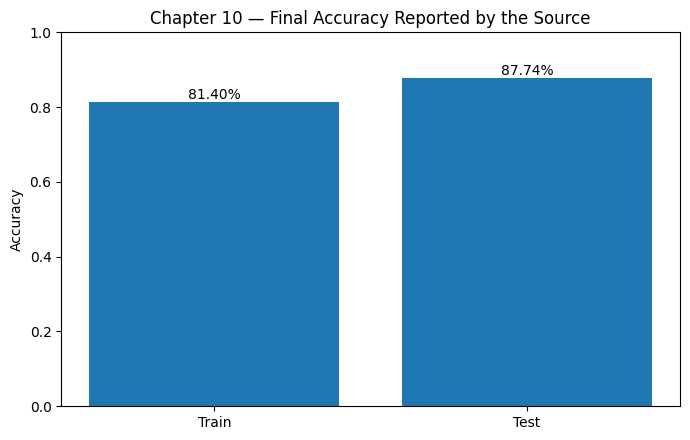

In [16]:
# Data output akhir yang tertulis pada source Chapter 10.
test_acc = 0.8774
train_acc = 0.814

plt.figure(figsize=(7, 4.5))
bars = plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Chapter 10 — Final Accuracy Reported by the Source")
for b, v in zip(bars, [train_acc, test_acc]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Interpretasi

Angka di atas bukan hasil run ulang notebook ini; angka tersebut adalah **output yang tercetak pada source Chapter 10**.

Hal pentingnya bukan hanya angka akurasi, tetapi perubahan arsitektur: convolutional layer membuat model dapat menggunakan **small set of weights repeatedly** untuk banyak bagian gambar. Buku mengaitkan struktur tersebut dengan peningkatan generalization dan pengurangan kecenderungan overfitting.

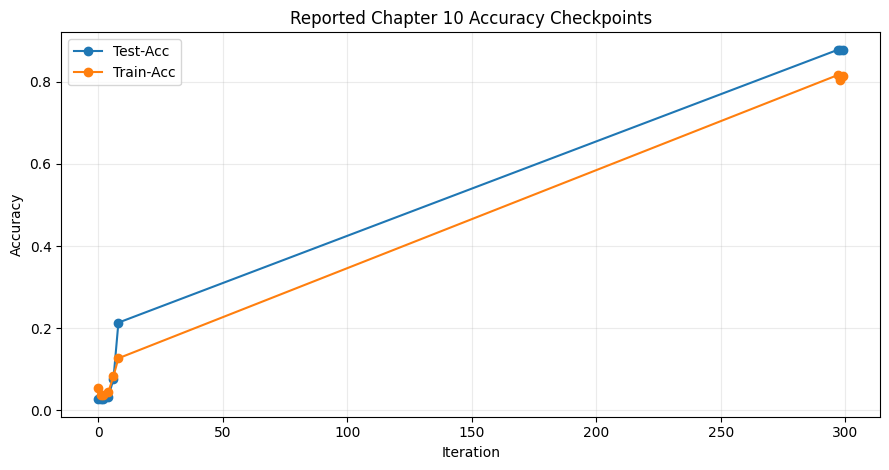

In [17]:
# Untuk memperlihatkan perkembangan training secara ringkas,
# gunakan checkpoint yang memang tersedia pada source.
iterations_source = np.array([0, 1, 2, 4, 6, 8, 297, 298, 299])
test_source = np.array([0.0288, 0.0273, 0.0280, 0.0339, 0.0760, 0.2137, 0.8774, 0.8774, 0.8774])
train_source = np.array([0.055, 0.037, 0.037, 0.046, 0.083, 0.127, 0.816, 0.804, 0.814])

plt.figure(figsize=(9, 4.8))
plt.plot(iterations_source, test_source, marker="o", label="Test-Acc")
plt.plot(iterations_source, train_source, marker="o", label="Train-Acc")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Reported Chapter 10 Accuracy Checkpoints")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Grafik checkpoint hanya menggunakan titik output yang tersedia pada hasil source yang berhasil diekstrak. Jadi garis di antara titik tersebut adalah **visualisasi penghubung**, bukan klaim bahwa buku mencetak semua nilai pada titik di antaranya.

## Mengapa CNN Membantu Generalization?

Inti Chapter 10 dapat diringkas menjadi:

**Same pattern → Same weights → Reuse across locations → More learning opportunities per parameter → Better generalization**

Misalnya, jika sebuah kernel belajar mengenali garis tertentu, kernel tersebut dapat mencari pola yang sama di berbagai posisi gambar. Tidak perlu membuat set weights baru untuk setiap lokasi.

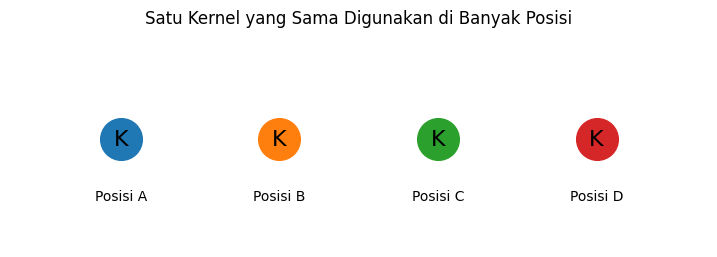

In [18]:
# Visual ringkas: satu kernel digunakan berulang di beberapa lokasi.
positions = ["Posisi A", "Posisi B", "Posisi C", "Posisi D"]

plt.figure(figsize=(9, 2.8))
for i, pos in enumerate(positions):
    plt.scatter(i, 0, s=900)
    plt.text(i, 0, "K", ha="center", va="center", fontsize=16)
    plt.text(i, -0.45, pos, ha="center")

plt.xlim(-0.7, len(positions)-0.3)
plt.ylim(-0.8, 0.8)
plt.axis("off")
plt.title("Satu Kernel yang Sama Digunakan di Banyak Posisi")
plt.show()

Visual ini bersifat konseptual: huruf **K** menunjukkan kernel yang sama, bukan nilai weights tertentu. Pesan utamanya adalah **weight sharing**, yaitu satu set weights dipakai di banyak lokasi.

## Stacked Convolutional Layers

Di bagian akhir chapter, buku menyebut bahwa convolutional layers umumnya dapat **ditumpuk** sehingga output dari satu convolutional layer menjadi input bagi convolutional layer berikutnya.

Hal ini penting karena:

- layer awal dapat mempelajari pola level rendah seperti edges;
- layer berikutnya dapat menggunakan representasi tersebut untuk pola yang lebih kompleks;
- penumpukan convolutional layers menjadi salah satu perkembangan penting yang memungkinkan neural networks menjadi sangat dalam.

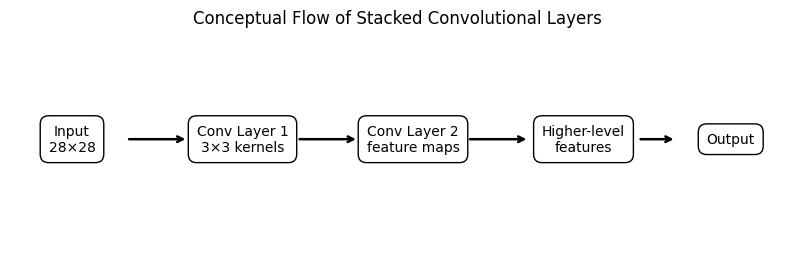

In [19]:
# Diagram arsitektur konseptual.
fig, ax = plt.subplots(figsize=(10, 2.8))
nodes = [
    (0.08, "Input\n28×28"),
    (0.30, "Conv Layer 1\n3×3 kernels"),
    (0.52, "Conv Layer 2\nfeature maps"),
    (0.74, "Higher-level\nfeatures"),
    (0.93, "Output")
]
for x, label in nodes:
    ax.text(x, 0.5, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.6", fill=False))
for (x1,_), (x2,_) in zip(nodes[:-1], nodes[1:]):
    ax.annotate("", xy=(x2-0.07,0.5), xytext=(x1+0.07,0.5),
                arrowprops=dict(arrowstyle="->", lw=1.8))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
ax.set_title("Conceptual Flow of Stacked Convolutional Layers")
plt.show()

## Concept Check

| Pertanyaan | Jawaban inti |
|---|---|
| Mengapa weights digunakan kembali? | Untuk mendeteksi feature yang sama di banyak lokasi tanpa membuat weights baru untuk setiap lokasi. |
| Apa itu convolutional kernel? | Mini linear layer dengan sedikit input yang digunakan berulang pada berbagai posisi. |
| Mengapa output 8×8 dengan kernel 3×3 menjadi 6×6? | Karena kernel dapat ditempatkan pada 6 posisi vertikal × 6 posisi horizontal tanpa padding. |
| Apa yang dihasilkan oleh 4 kernels? | Empat prediction matrices; pada contoh 8×8 → masing-masing berukuran 6×6. |
| Apa fungsi max pooling? | Memilih respons terbesar dari beberapa kernel pada posisi yang sama. |
| Apa ide utama implementasi NumPy? | Mengumpulkan subregion, merapikannya, lalu menggunakan dot product dengan kernels. |

## Key Takeaways

1. **Reusing weights** adalah ide utama Chapter 10.
2. Convolutional layer menggunakan banyak **small linear layers** yang dipakai ulang.
3. Kernel berpindah ke berbagai posisi gambar sehingga satu weights dapat mendeteksi pola yang sama di banyak tempat.
4. Beberapa kernels memungkinkan model belajar beberapa jenis pola.
5. Pooling menggabungkan respons dari berbagai kernels pada posisi yang sama.
6. Implementasi NumPy dapat mengubah convolution menjadi operasi matrix multiplication.
7. Source Chapter 10 melaporkan **87.74% Test-Acc** pada iterasi 299.
8. Konsep yang paling penting: **ketika sebuah network membutuhkan ide yang sama di banyak tempat, gunakan weights yang sama di tempat-tempat tersebut.**

## Chapter Summary

Chapter 10 memperkenalkan **Convolutional Neural Networks** melalui prinsip *structure*. Daripada memberi weights berbeda pada setiap lokasi gambar, convolutional layer menggunakan kernel kecil yang sama berulang kali. Dengan cara ini, kernel dapat mencari pola seperti edges atau bentuk lokal di seluruh gambar.

Secara komputasional, setiap posisi menghasilkan respons dari kernel, beberapa kernel menghasilkan beberapa feature maps, lalu hasil tersebut dapat digabungkan melalui pooling. Implementasi NumPy pada chapter menunjukkan bahwa operasi tersebut dapat diorganisasi menggunakan ekstraksi subregion dan dot product.

Hasil akhir yang dilaporkan sumber menunjukkan bahwa penggantian first layer menjadi convolutional layer mencapai **Test-Acc 0.8774** pada iterasi 299.

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

Notebook ini mengikuti struktur, istilah, konfigurasi, kode inti, dan output Chapter 10 dari buku. Visual tambahan yang diberi label **illustrative**, **conceptual**, atau **structural** dibuat untuk membantu memahami konsep dan bukan diklaim sebagai output eksperimen asli buku.